## Exercise: Applicability Domain
Task:
- Calculate applicability metrics to for the internal and the external test set of the previous exercise (when_to_trust_a_model.ipynb)


In [2]:
# imports
import numpy as np
import pandas as pd

from sklearn.neighbors import NearestNeighbors
from sklearn.covariance import EmpiricalCovariance
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler

from scipy.stats import chi2

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import DataStructs
from rdkit import Chem
from rdkit.Chem import Draw

from IPython.display import display, Markdown

from utils import maccs_fp_from_smiles, maccs_fp_from_smiles_as_bitvectors

### 1. Load results table from previous exercise
'esol_train_test_ext.csv' created by when_to_trust_a_model.ipynp

In [3]:
df = pd.read_csv('esol_train_test_ext.csv')

# Create data frames for esol training test set and external test compounds to save AD metrics later

# ESOL training data
train_df = df[df['Source']=='esol_train'].copy()

# ESOL test data
test_df = df[df['Source'] == 'esol_test'].copy()
# add absolute prediction error (residual)
test_df['Error'] = np.abs(test_df['LogP'] - test_df['LogP_predicted'])

# External test data
ext_df = df[df['Source'] == 'external_test'].copy()

# calculate fingerprints
X_esol_train, _ = maccs_fp_from_smiles(train_df['SMILES'])
X_esol_test,  _ = maccs_fp_from_smiles(test_df['SMILES'])
X_ext_test,   _ = maccs_fp_from_smiles(ext_df['SMILES'])

### 2. Test different AD metrics
#### 2.1 Leverage (Hat Matrix)

Leverage measures the distance to the center of the training space

In [19]:
cov = EmpiricalCovariance().fit(X_esol_train) # shape of descriptor space

# Mahalanobis distance of X_test to descriptor space
leverage_esol_test = cov.mahalanobis(X_esol_test) 
test_df['Leverage'] = leverage_esol_test

# external test data
leverage_esol_ext = cov.mahalanobis(X_ext_test)
ext_df['Leverage'] = leverage_esol_ext

print(f'Average leverage by test set: \n'
      f'ESOL test: {leverage_esol_test.mean()} \n'
      f'External test: {leverage_esol_ext.mean()}')

Average leverage by test set: 
ESOL test: 170.57480703116312 
External test: 1681.1144734164686


AD threshold: 198.15417677134099


<Axes: xlabel='PC1', ylabel='PC2'>

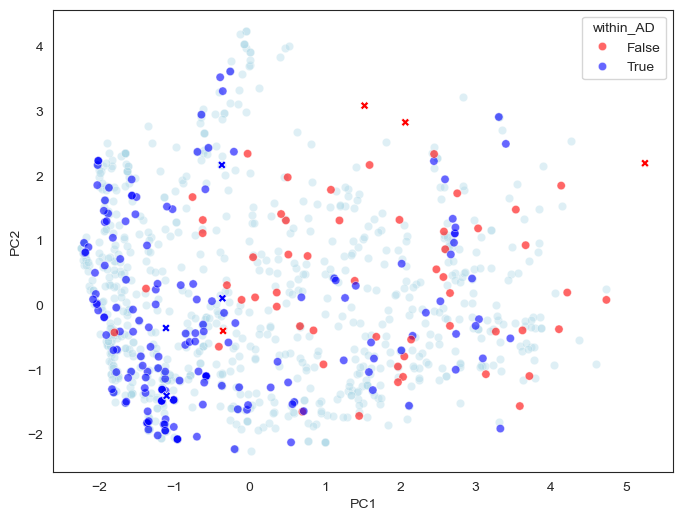

In [5]:
# Typical threshold: use Chi-square distribution with a confidence level
# confidence level: 95%
# df: degrees of freedom
# chi2.ppf: Chi-square distribution, percent point function (inverse of cdf)
threshold = chi2.ppf(0.95, df=X_esol_train.shape[1])
print('AD threshold:', threshold)

# plot training data
plt.figure(figsize=(8, 6))
sns.set_style('white')
sns.scatterplot(train_df, x='PC1', y='PC2', 
                color='lightblue', alpha=0.4)

# plot test data and whether they are within the AD
test_df['within_AD'] = test_df['Leverage'] < threshold
sns.scatterplot(test_df, x='PC1', y='PC2', 
                palette=['red','blue'], hue='within_AD', alpha=0.6)

# plot external test data and whether they are within the AD
ext_df['within_AD'] = ext_df['Leverage'] < threshold
sns.scatterplot(ext_df, x='PC1', y='PC2', 
                palette=['red','blue'], hue='within_AD', alpha=1, legend=False, marker='X')

#### 2.2 Kernel Density Estimation (KDE)

Low density indicates poor coverage by the training data.

In [6]:
# KDE works better with continuous variables,
# so we calculate density on the 3 principal components
pc_list = ['PC1', 'PC2', 'PC3']
pca_X_train = df[df['Source']=='esol_train'][pc_list]
pca_X_test  = df[df['Source']=='esol_test'][pc_list]
pca_X_ext   = df[df['Source']=='external_test'][pc_list]

In [7]:
kde = KernelDensity(kernel="gaussian", bandwidth=1.0)
scaler = StandardScaler() # scale values between -1 and 1
pca_X_train_standard = scaler.fit_transform(pca_X_train)
kde.fit(pca_X_train_standard) # Gaussian kernel density estimate for the training data

# esol test data
pca_X_test_standard = scaler.transform(pca_X_test)
kernel_density_esol = kde.score_samples(pca_X_test_standard) # log-likelihood of each sample
test_df['Kernel_Density'] = kernel_density_esol

# external test data
pca_X_ext_standard = scaler.transform(pca_X_ext)
kernel_density_ext = kde.score_samples(pca_X_ext_standard)
ext_df['Kernel_Density'] = kernel_density_ext

print(f'Average of kernel densities by test set: \n'
      f'ESOL test: {kernel_density_esol.mean()} \n'
      f'External test: {kernel_density_ext.mean()}')

Average of kernel densities by test set: 
ESOL test: -4.397127703532953 
External test: -4.893990045494805


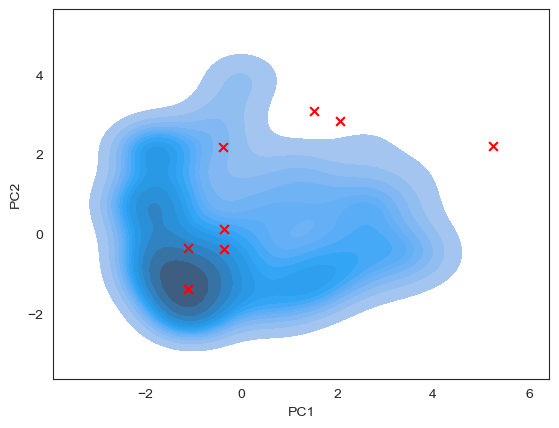

In [8]:
# Visualize kernel density of the training space in 2D
kde_train_data = train_df[['PC1', 'PC2']]
sns.kdeplot(kde_train_data, x='PC1', y='PC2', fill=True, levels=15)
plt.scatter(ext_df['PC1'], ext_df['PC2'], marker='x', color='red', alpha=1, s=40)
plt.show()

#### 2.3 - Distance to k-nearest Neighbors
Average distance of test compounds to training data

In [9]:
nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(X_esol_train)

# esol test data
dist_esol, _ = nbrs.kneighbors(X_esol_test)
knn_dist_esol = dist_esol.mean(axis=1)
test_df['kNN_Distance'] = knn_dist_esol

# external test data
dist_ext, neighbors_ext = nbrs.kneighbors(X_ext_test)
knn_dist_ext = dist_ext.mean(axis=1)
ext_df['kNN_Distance'] = knn_dist_ext

print(f'Average of average distances by test set: \n'
      f'ESOL test: {knn_dist_esol.mean()} \n'
      f'External test: {knn_dist_ext.mean()}')

Average of average distances by test set: 
ESOL test: 2.078887150432273 
External test: 3.721727006777787


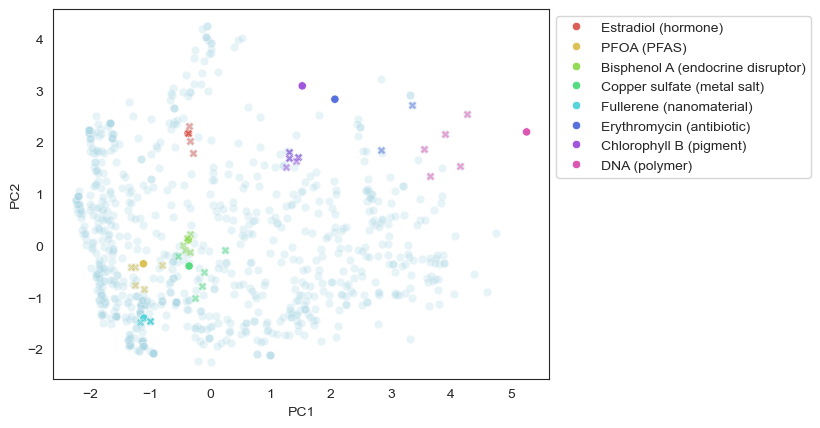

In [10]:
# plot nearest neighbors with distances
nbrs = NearestNeighbors(n_neighbors=5)
# fit on standardized PC1 and PC2 coordinates
nbrs.fit(pca_X_train_standard)
# get nearest neighbors of external test data in 2D 
dist_ext, neighbors_ext = nbrs.kneighbors(pca_X_ext_standard)

# Background: training data
ax = sns.scatterplot(train_df, x='PC1', y='PC2', 
                color='lightblue', alpha=0.3)
palette = sns.color_palette('hls', n_colors=neighbors_ext.shape[0])
# Add external test substances
sns.scatterplot(ext_df, x='PC1', y='PC2', 
                palette=palette, hue='Name')
# Add 5 nearest neighbors external test substances
for i, neighbors in enumerate(neighbors_ext):
    highlight = train_df.iloc[neighbors]
    sns.scatterplot(highlight, x='PC1', y='PC2', color=palette[i], marker='X', alpha=0.5)
    
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1)) # move legend outside of plot
plt.show()


#### 2.4 - Chemical similarity (Tanimoto similarity to nearest neighbor)
Distance of test compounds to training data

Tanimoto Similarity Index: similarity to the most similar molecules. Can be adapted to average similarity over k most similar molecules


In [11]:
def get_tanimoto_nearest_neighbor(fps_test, fps_train):
      sim_list = [] # similarity list
      nn_list = [] # nearest neighbor list
      for i in range(len(fps_test)):
          sims = DataStructs.BulkTanimotoSimilarity(fps_test[i], fps_train)
          sims[i] = -1 # remove self similarity
          nearest_neighbor_idx = int(np.argmax(sims)) # get the highest similarity
          nn_list.append(nearest_neighbor_idx) # get the nearest neighbor
          sim_list.append(sims[nearest_neighbor_idx]) # get the similarity to the nearest neighbor
      return np.array(sim_list), nn_list

# Tanimoto similarity to nearest neighbor - BulkTanimotoSimilarity needs descriptors as bitvectors
X_esol_train_bitvec = maccs_fp_from_smiles_as_bitvectors(df[df['Source']=='esol_train']['SMILES'])
X_esol_test_bitvec = maccs_fp_from_smiles_as_bitvectors(df[df['Source']=='esol_test']['SMILES'])
X_ext_test_bitvec = maccs_fp_from_smiles_as_bitvectors(df[df['Source']=='external_test']['SMILES'])
      
# Tanimoto similarity of esol test to esol train
tanimoto_sim_test, nn_test = get_tanimoto_nearest_neighbor(X_esol_test_bitvec, X_esol_train_bitvec)
test_df['Tanimoto_Similarity'] = tanimoto_sim_test

# Tanimoto similarity of external test molecules to esol train
tanimoto_sim_ext, nn_ext = get_tanimoto_nearest_neighbor(X_ext_test_bitvec, X_esol_train_bitvec)
ext_df['Tanimoto_Similarity'] = tanimoto_sim_ext

print(f'Average of closest tanimoto distance to training data: \n'
      f'ESOL test: {np.mean(tanimoto_sim_test)} \n'
      f'External test: {np.mean(tanimoto_sim_ext)}')

Average of closest tanimoto distance to training data: 
ESOL test: 0.8667161852627483 
External test: 0.647028699372853


### Pair 1129 — Similarity: **1.00**

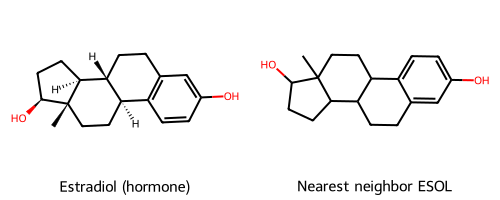

### Pair 1130 — Similarity: **0.42**

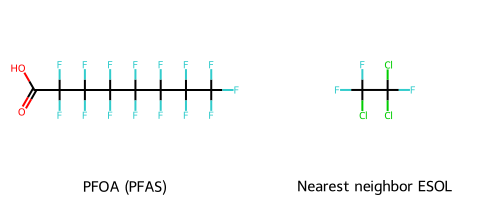

### Pair 1131 — Similarity: **0.70**

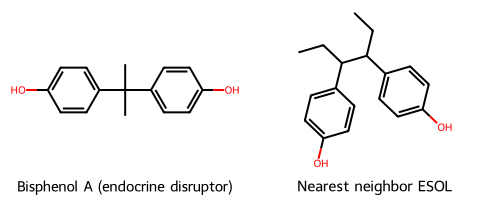

### Pair 1132 — Similarity: **0.38**

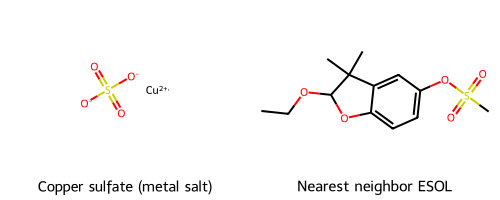

### Pair 1133 — Similarity: **0.89**

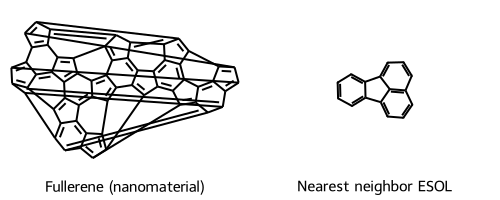

### Pair 1134 — Similarity: **0.56**

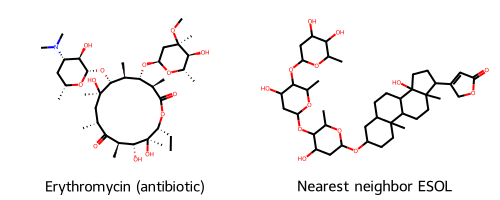

### Pair 1135 — Similarity: **0.55**

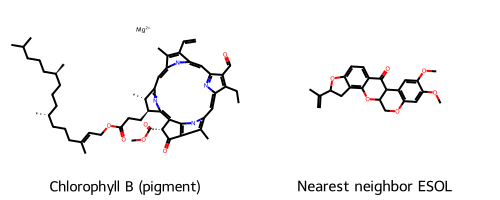

### Pair 1136 — Similarity: **0.68**

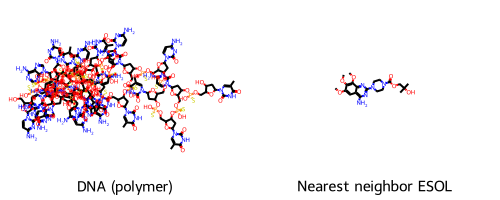

In [12]:
# print most similar molecules and scores of external test set
ext_df['Tanimoto_NearestNeighbor'] = train_df.iloc[nn_ext]['SMILES'].values

# create mol objects
ext_df["Tanimoto_NearestNeighbor_mol"] = ext_df["Tanimoto_NearestNeighbor"].apply(Chem.MolFromSmiles)
ext_df["SMILES_mol"] = ext_df["SMILES"].apply(Chem.MolFromSmiles)

# Draw table
for i, row in ext_df.iterrows():
    img = Draw.MolsToGridImage(
        [row["SMILES_mol"], row["Tanimoto_NearestNeighbor_mol"]],
        molsPerRow=2,
        subImgSize=(250, 200),
        legends=[row['Name'], "Nearest neighbor ESOL"],
    )

    display(Markdown(f"### Pair {i+1} — Similarity: **{row['Tanimoto_Similarity']:.2f}**"))
    display(img)



maccskeys or whatever its name is only checks if a functiolal group is there it doesnt cout if is there multiple times --> thats why last example DNA is similar

In [13]:
ext_df['Tanimoto_NearestNeighbor']

1128                     CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O
1129                                  FC(F)(Cl)C(F)(Cl)Cl
1130                     CCC(C(CC)c1ccc(O)cc1)c2ccc(O)cc2
1131                    CCOC2Oc1ccc(OS(C)(=O)=O)cc1C2(C)C
1132                           c1ccc2c(c1)c3cccc4cccc2c34
1133    CC1OC(CC(O)C1O)OC2C(O)CC(OC2C)OC8C(O)CC(OC7CCC...
1134     COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C 
1135    COc2cc1c(N)nc(nc1c(OC)c2OC)N3CCN(CC3)C(=O)OCC(...
Name: Tanimoto_NearestNeighbor, dtype: object

## 3. Compare AD metrics 
Question: Do the AD metrics correlate to the prediction error (residual)?
Compare AD metrics with prediction errors on test set

/Users/raphaeland./opt/anaconda3/envs/DAC_env/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


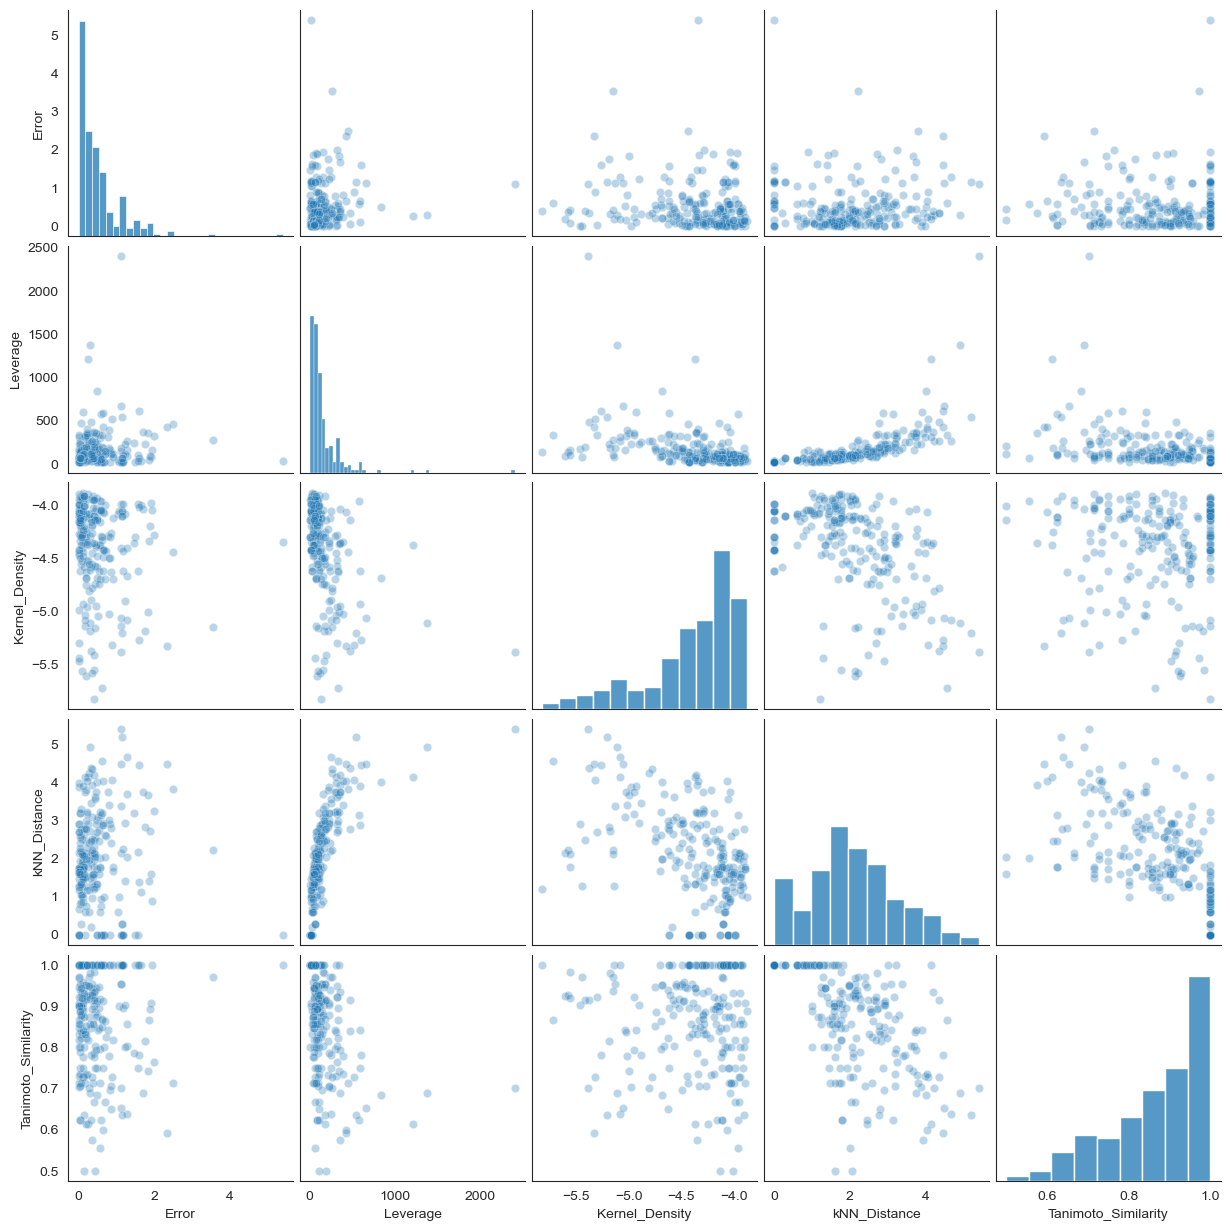

In [14]:
sns.pairplot(test_df, vars=['Error',  
                            'Leverage', 
                            'Kernel_Density',
                            'kNN_Distance',
                            'Tanimoto_Similarity',
                            ],
             plot_kws=dict(alpha=0.3))
plt.show()

How do these metrics look like in the chemical space?


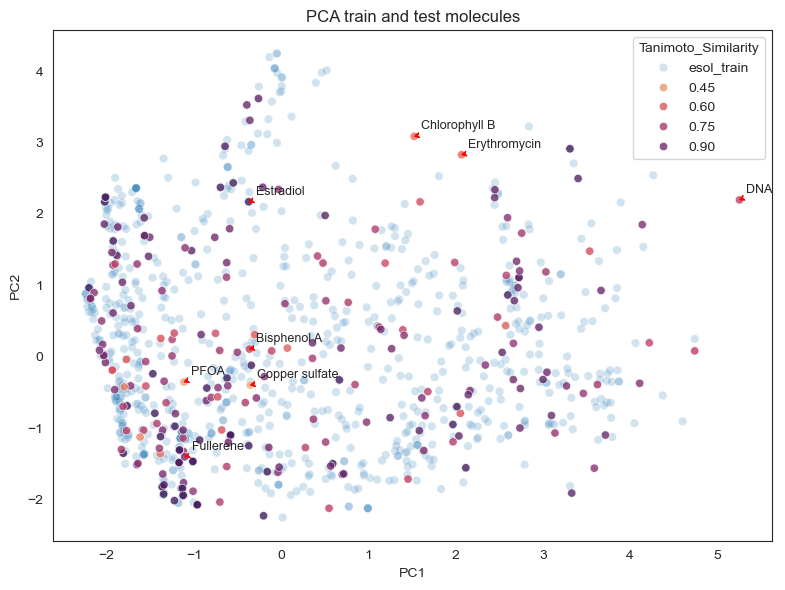

In [22]:
# merge data
merged_data = pd.concat([test_df, ext_df], axis=0)

plt.close()
plt.figure(figsize=(8, 6))
sns.set_style('white')

# Option 1: Color by data source (training data vs. predicted values)
sns.scatterplot(df[df['Source']=='esol_train'], 
                x='PC1', y='PC2', 
                alpha=0.2, hue='Source', color='lightgrey')
# Look at Error
sns.scatterplot(merged_data, x='PC1', y='PC2', alpha=0.8, hue='Tanimoto_Similarity', palette='flare')
# or look at AD metric: 'Leverage', 'Kernel_Density', 'kNN_Distance', 'Tanimoto_Similarity'
# sns.scatterplot(merged_data, x='PC1', y='PC2', alpha=1, hue='Leverage', palette='flare')

# annotate test molecules
ext_df.reset_index(drop=True, inplace=True)
# plt.scatter(ext_df['PC1'], ext_df['PC2'], marker='o', color='red', alpha=0.5, s=30)
for i, name in enumerate(ext_df['Name']):
    plt.annotate(name.split('(')[0],(ext_df['PC1'][i], ext_df['PC2'][i]),
                 fontsize=9, xytext=(5, 5), textcoords='offset points',
                 arrowprops=dict(arrowstyle='fancy', color='red', lw=0.5)
    )

plt.title('PCA train and test molecules')
plt.tight_layout()
plt.show()

Now, let's go back to our test molecules and look at the AD metrics:

In [16]:
ext_df[['Name', 'LogP_predicted', 'Tanimoto_Similarity', 'kNN_Distance', 'Leverage', 'Kernel_Density']]

,Name,LogP_predicted,Tanimoto_Similarity,kNN_Distance,Leverage,Kernel_Density
0,Estradiol (hormone),3.532695,1.000000,1.579796,118.814309,-5.278910
1,PFOA (PFAS),2.638068,0.416667,2.755357,140.467219,-3.880333
2,Bisphenol A (endocrine disruptor),3.906703,0.695652,2.789671,103.432158,-4.354049
3,Copper sulfate (metal salt),0.562311,0.381818,4.999200,8164.201409,-3.996080
4,Fullerene (nanomaterial),4.555509,0.888889,1.000000,52.050433,-4.065915
5,Erythromycin (antibiotic),2.055715,0.560606,5.440401,675.269056,-5.556249
6,Chlorophyll B (pigment),5.011746,0.548387,5.439777,2436.332963,-5.606630
7,DNA (polymer),1.501299,0.684211,5.769615,1758.348240,-6.413755


Discuss:
- Which AD metric seems to work best for the chosen combination of fingerprint and modelling approach?
- How would you define a AD threshold for each metric?
- For which molecules would you trust the LogP predictions?

AD what you tell people to use your model for / what it can't be used